<a href="https://colab.research.google.com/github/lsiem10/my-first-binder/blob/main/MarathonProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [30]:
df = pd.read_csv("marathon_results_2017.csv")

In [31]:
df = df [["Age", "5K", "Half", "Official Time"]]

In [32]:
df["5K_min"] = pd.to_timedelta(df["5K"], errors="coerce").dt.total_seconds() / 60
df["Half_min"] = pd.to_timedelta(df["Half"], errors="coerce").dt.total_seconds() / 60
df["Official_min"] = pd.to_timedelta(df["Official Time"], errors="coerce").dt.total_seconds() / 60

In [37]:
df = df.dropna(
    subset=["Age","5K_min","Half_min","Official_min"]
)

In [33]:
df["EarlyPace"] = df["5K_min"] / 3.1
df["SecondHalfTime"] = df["Official_min"] - df["Half_min"]
df["SecondHalfPace"] = df["SecondHalfTime"] / 13.1
df["Slowdown"] = df["SecondHalfPace"] - df["EarlyPace"]

In [34]:
print(len(df))

df[["Age","EarlyPace","Slowdown"]].describe()

26410


,Age,EarlyPace,Slowdown
count,26410.000000,26385.000000,26375.000000
mean,42.587732,8.244164,1.491966
std,11.419467,1.284675,1.275715
min,18.000000,4.967742,-6.722359
25%,34.000000,7.317204,0.604716
50%,43.000000,8.086022,1.230075
75%,51.000000,8.951613,2.107753
max,84.000000,17.494624,16.803579


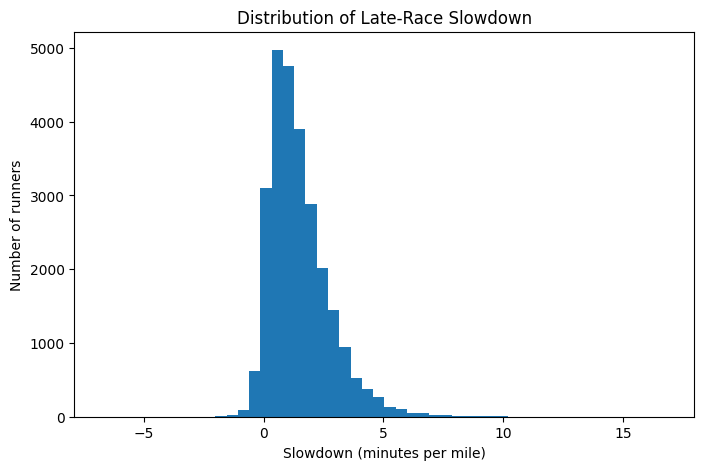

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df["Slowdown"], bins=50)

plt.xlabel("Slowdown (minutes per mile)")
plt.ylabel("Number of runners")
plt.title("Distribution of Late-Race Slowdown")

plt.show()

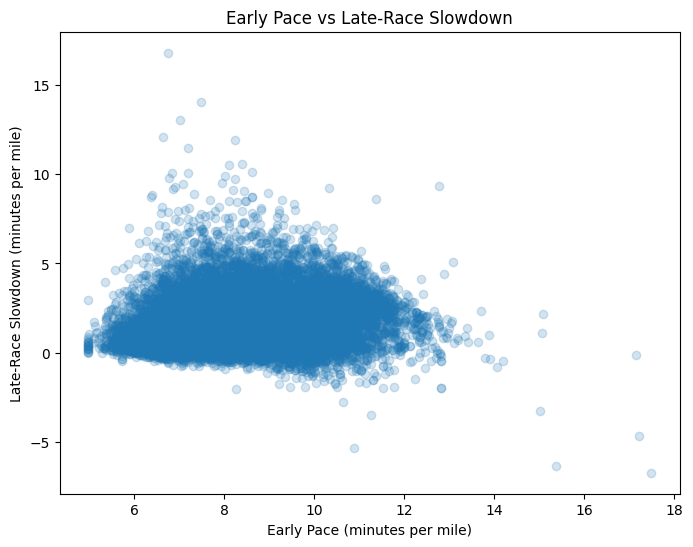

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["EarlyPace"],
    df["Slowdown"],
    alpha=0.2
)

plt.xlabel("Early Pace (minutes per mile)")
plt.ylabel("Late-Race Slowdown (minutes per mile)")
plt.title("Early Pace vs Late-Race Slowdown")

plt.show()

In [38]:
X = df["EarlyPace"]
X = sm.add_constant(X)

y = df["Slowdown"]

model1 = sm.OLS(y, X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               Slowdown   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     719.5
Date:                Fri, 29 May 2026   Prob (F-statistic):          2.13e-156
Time:                        01:16:30   Log-Likelihood:                -43492.
No. Observations:               26375   AIC:                         8.699e+04
Df Residuals:                   26373   BIC:                         8.700e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1578      0.050      3.134      0.0

In [39]:
X = df[["EarlyPace", "Age"]]
X = sm.add_constant(X)

y = df["Slowdown"]

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               Slowdown   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     482.4
Date:                Fri, 29 May 2026   Prob (F-statistic):          1.74e-206
Time:                        01:16:39   Log-Likelihood:                -43373.
No. Observations:               26375   AIC:                         8.675e+04
Df Residuals:                   26372   BIC:                         8.678e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1394      0.054     -2.598      0.0